# Current Data Analysis

Notebook này phân tích **bộ dữ liệu hiện tại** đang có trong project để phục vụ:
- hiểu rõ số lượng dữ liệu đang có
- biết có những mã nào trong `VN30`
- xem coverage thời gian của `VNINDEX`, `VN30`, và `training panel`
- minh hoạ pipeline processing từ **raw market data** sang **training panel** và **feature engineering**

Phạm vi notebook:
1. Inventory các file dữ liệu chính
2. Raw market universe: `VNINDEX` và `VN30`
3. Training panel market-level dùng cho model hiện tại
4. Processing cụ thể: raw -> panel -> features -> label availability

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path('/Users/mac/Documents/Dự án Agent Tài chính')
SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.matplotlib'))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from risk_dashboard.quant.xgb_engine import FEATURE_COLS, HORIZON_SPECS, prepare_features

UNIVERSE_MANIFEST_PATH = PROJECT_ROOT / 'data/cache/market_universe_manifest_20260329T153317Z_c80964fc.json'
with UNIVERSE_MANIFEST_PATH.open('r', encoding='utf-8') as f:
    universe_manifest = json.load(f)

TRAINING_MANIFEST_PATH = Path(universe_manifest['training_panel_manifest'])
with TRAINING_MANIFEST_PATH.open('r', encoding='utf-8') as f:
    training_manifest = json.load(f)

VN30_PATH = Path(universe_manifest['vn30_parquet'])
VNINDEX_PATH = Path(universe_manifest['vnindex_parquet'])
PANEL_PATH = Path(universe_manifest['training_panel_parquet'])
CONSTITUENTS_PATH = Path(universe_manifest['constituents_csv'])

vn30_df = pd.read_parquet(VN30_PATH)
vnindex_df = pd.read_parquet(VNINDEX_PATH)
panel_df = pd.read_parquet(PANEL_PATH)
constituents_df = pd.read_csv(CONSTITUENTS_PATH)

vn30_df['time'] = pd.to_datetime(vn30_df['time'])
vnindex_df['time'] = pd.to_datetime(vnindex_df['time'])
panel_df['date'] = pd.to_datetime(panel_df['date'])

for col in ['open', 'high', 'low', 'close', 'volume']:
    if col in vn30_df.columns:
        vn30_df[col] = pd.to_numeric(vn30_df[col], errors='coerce')
    if col in vnindex_df.columns:
        vnindex_df[col] = pd.to_numeric(vnindex_df[col], errors='coerce')

panel_features_df = prepare_features(panel_df)

print('VN30 rows:', len(vn30_df))
print('VNINDEX rows:', len(vnindex_df))
print('Panel rows:', len(panel_df))

VN30 rows: 73410
VNINDEX rows: 1437
Panel rows: 1437


In [2]:
inventory = pd.DataFrame(
    [
        {
            'dataset': 'VN30 raw daily parquet',
            'path': str(VN30_PATH),
            'rows': len(vn30_df),
            'start': vn30_df['time'].min(),
            'end': vn30_df['time'].max(),
        },
        {
            'dataset': 'VNINDEX raw daily parquet',
            'path': str(VNINDEX_PATH),
            'rows': len(vnindex_df),
            'start': vnindex_df['time'].min(),
            'end': vnindex_df['time'].max(),
        },
        {
            'dataset': 'Training panel parquet',
            'path': str(PANEL_PATH),
            'rows': len(panel_df),
            'start': panel_df['date'].min(),
            'end': panel_df['date'].max(),
        },
        {
            'dataset': 'VN30 constituents csv',
            'path': str(CONSTITUENTS_PATH),
            'rows': len(constituents_df),
            'start': pd.NaT,
            'end': pd.NaT,
        },
    ]
)

display(Markdown('## Data Inventory'))
display(inventory)
display(training_manifest)

## Data Inventory

,dataset,path,rows,start,end
0,VN30 raw daily parquet,/Users/mac/Documents/Dự án Agent Tài chín...,73410,2015-01-05,2026-03-27
1,VNINDEX raw daily parquet,/Users/mac/Documents/Dự án Agent Tài chín...,1437,2020-05-11,2026-03-27
2,Training panel parquet,/Users/mac/Documents/Dự án Agent Tài chín...,1437,2020-05-11,2026-03-27
3,VN30 constituents csv,/Users/mac/Documents/Dự án Agent Tài chín...,30,NaT,NaT


{'ingest_id': 'c80964fc-6b40-4f2d-84ee-594ec1964fd6',
 'created_at': '2026-03-29T15:33:34.876519+00:00',
 'market_source': 'vnstock:VNINDEX:DNSE',
 'macro_source': 'auto:yfinance:USDVND=X+worldbank',
 'start': '2015-01-01',
 'end': '2026-03-29',
 'n_rows': 1437,
 'columns': ['date',
  'vn_index',
  'volume',
  'usd_vnd_rate',
  'usd_vnd_1m_change_pct',
  'cpi_yoy_pct',
  'sbv_interest_rate_pct',
  'fdi_disbursement_yoy_pct',
  'volume_1w_trend_pct']}

In [3]:
ticker_summary = (
    vn30_df.groupby('ticker')
    .agg(
        n_rows=('time', 'size'),
        first_date=('time', 'min'),
        last_date=('time', 'max'),
        last_close=('close', 'last'),
        avg_volume=('volume', 'mean'),
    )
    .sort_values(['n_rows', 'ticker'], ascending=[False, True])
    .reset_index()
)

display(Markdown('## VN30 Universe Overview'))
display(pd.DataFrame({
    'metric': ['unique_tickers', 'rows_total', 'start', 'end'],
    'value': [vn30_df['ticker'].nunique(), len(vn30_df), vn30_df['time'].min(), vn30_df['time'].max()],
}))
display(ticker_summary.head(10))
display(ticker_summary.tail(10))

## VN30 Universe Overview

,metric,value
0,unique_tickers,30
1,rows_total,73410
2,start,2015-01-05 00:00:00
3,end,2026-03-27 00:00:00


,ticker,n_rows,first_date,last_date,last_close,avg_volume
0,BID,2802,2015-01-05,2026-03-27,39.85,2.398323e+06
1,BVH,2802,2015-01-05,2026-03-27,84.00,5.909462e+05
2,CTG,2802,2015-01-05,2026-03-27,34.80,5.806634e+06
3,FPT,2802,2015-01-05,2026-03-27,76.10,2.428354e+06
4,GAS,2802,2015-01-05,2026-03-27,82.10,7.603338e+05
5,HPG,2802,2015-01-05,2026-03-27,26.50,1.585224e+07
6,MBB,2802,2015-01-05,2026-03-27,26.15,9.863647e+06
7,MSN,2802,2015-01-05,2026-03-27,73.30,1.982729e+06
8,MWG,2802,2015-01-05,2026-03-27,81.00,2.713073e+06
9,SSI,2802,2015-01-05,2026-03-27,27.05,1.131331e+07


,ticker,n_rows,first_date,last_date,last_close,avg_volume
20,VPB,2149,2017-08-17,2026-03-27,26.45,1.248989e+07
21,VRE,2093,2017-11-06,2026-03-27,25.75,5.034100e+06
22,HDB,2050,2018-01-05,2026-03-27,25.30,5.447011e+06
23,BCM,2017,2018-02-21,2026-03-27,54.30,2.832764e+05
24,POW,2006,2018-03-06,2026-03-27,13.05,8.493214e+06
25,GVR,1998,2018-03-21,2026-03-27,32.10,2.644470e+06
26,TPB,1983,2018-04-19,2026-03-27,16.25,6.305178e+06
27,VHM,1966,2018-05-17,2026-03-27,103.00,4.363104e+06
28,TCB,1954,2018-06-04,2026-03-27,30.65,8.773467e+06
29,SSB,1251,2021-03-24,2026-03-27,16.90,1.897412e+06


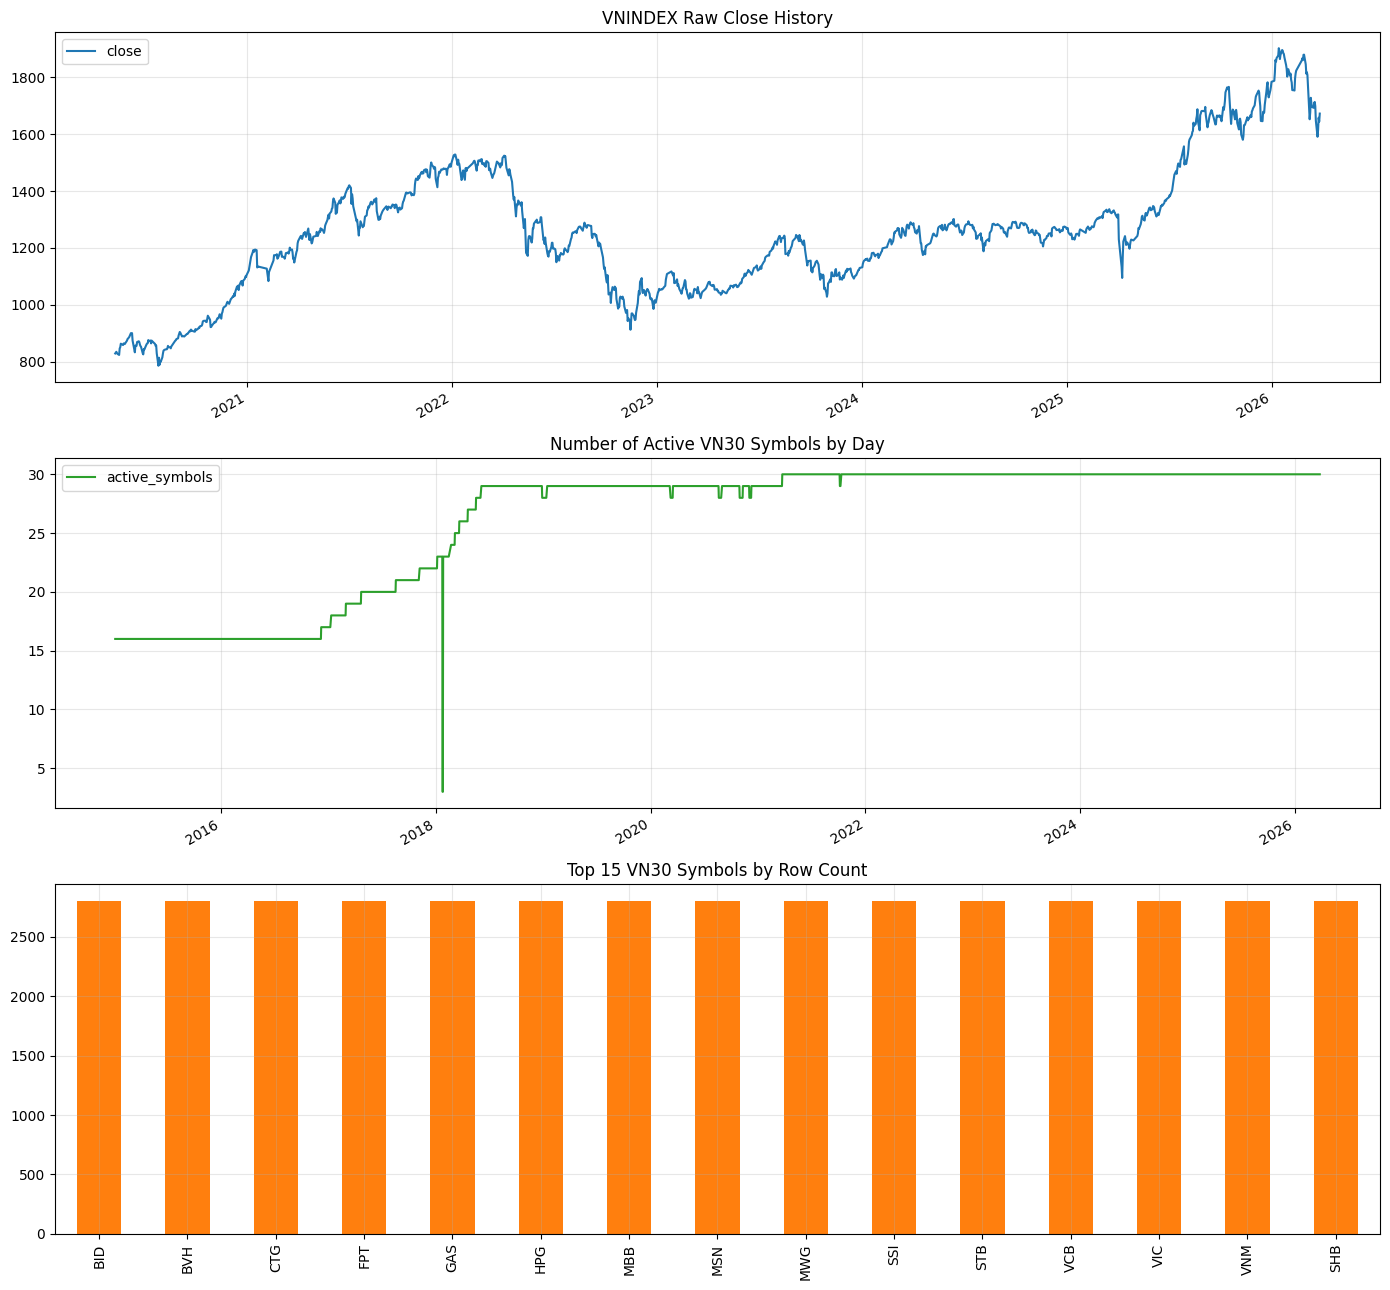

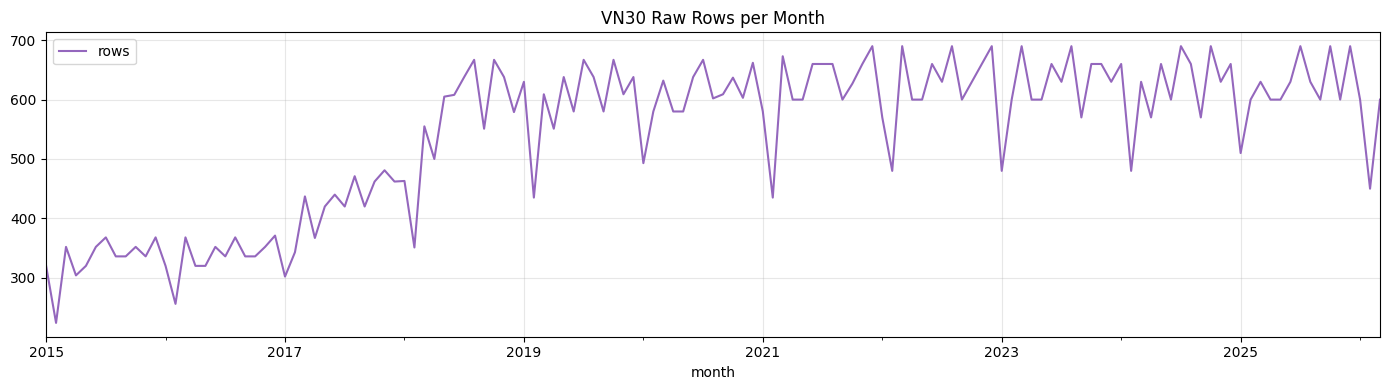

In [4]:
active_symbols_daily = vn30_df.groupby('time')['ticker'].nunique().rename('active_symbols').reset_index()
rows_per_month = vn30_df.assign(month=vn30_df['time'].dt.to_period('M').dt.to_timestamp()).groupby('month').size().rename('rows').reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=False)

vnindex_df.plot(x='time', y='close', ax=axes[0], color='tab:blue', title='VNINDEX Raw Close History')
active_symbols_daily.plot(x='time', y='active_symbols', ax=axes[1], color='tab:green', title='Number of Active VN30 Symbols by Day')
ticker_summary.sort_values('n_rows', ascending=False).head(15).plot.bar(x='ticker', y='n_rows', ax=axes[2], color='tab:orange', legend=False, title='Top 15 VN30 Symbols by Row Count')

for ax in axes:
    ax.grid(alpha=0.3)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
rows_per_month.plot(x='month', y='rows', ax=ax, color='tab:purple', title='VN30 Raw Rows per Month')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Training Panel Overview

,metric,value
0,panel_rows,1437
1,panel_start,2020-05-11 00:00:00
2,panel_end,2026-03-27 00:00:00
3,panel_columns,"date, vn_index, volume, usd_vnd_rate, usd_vnd_..."


,date,vn_index,volume,usd_vnd_rate,usd_vnd_1m_change_pct,cpi_yoy_pct,sbv_interest_rate_pct,fdi_disbursement_yoy_pct,volume_1w_trend_pct
0,2020-05-11,828.33,353416000,23444.0,-0.791333,3.220934,7.6475,-1.985112,0.0
1,2020-05-13,834.21,374602816,23444.0,-0.791333,3.220934,7.6475,-1.985112,0.0
2,2020-05-15,827.03,301891136,23444.0,-0.791333,3.220934,7.6475,-1.985112,0.0
3,2020-05-18,823.23,29758024,23444.0,-0.791333,3.220934,7.6475,-1.985112,0.0
4,2020-05-19,845.92,385271840,23444.0,-0.791333,3.220934,7.6475,-1.985112,0.0


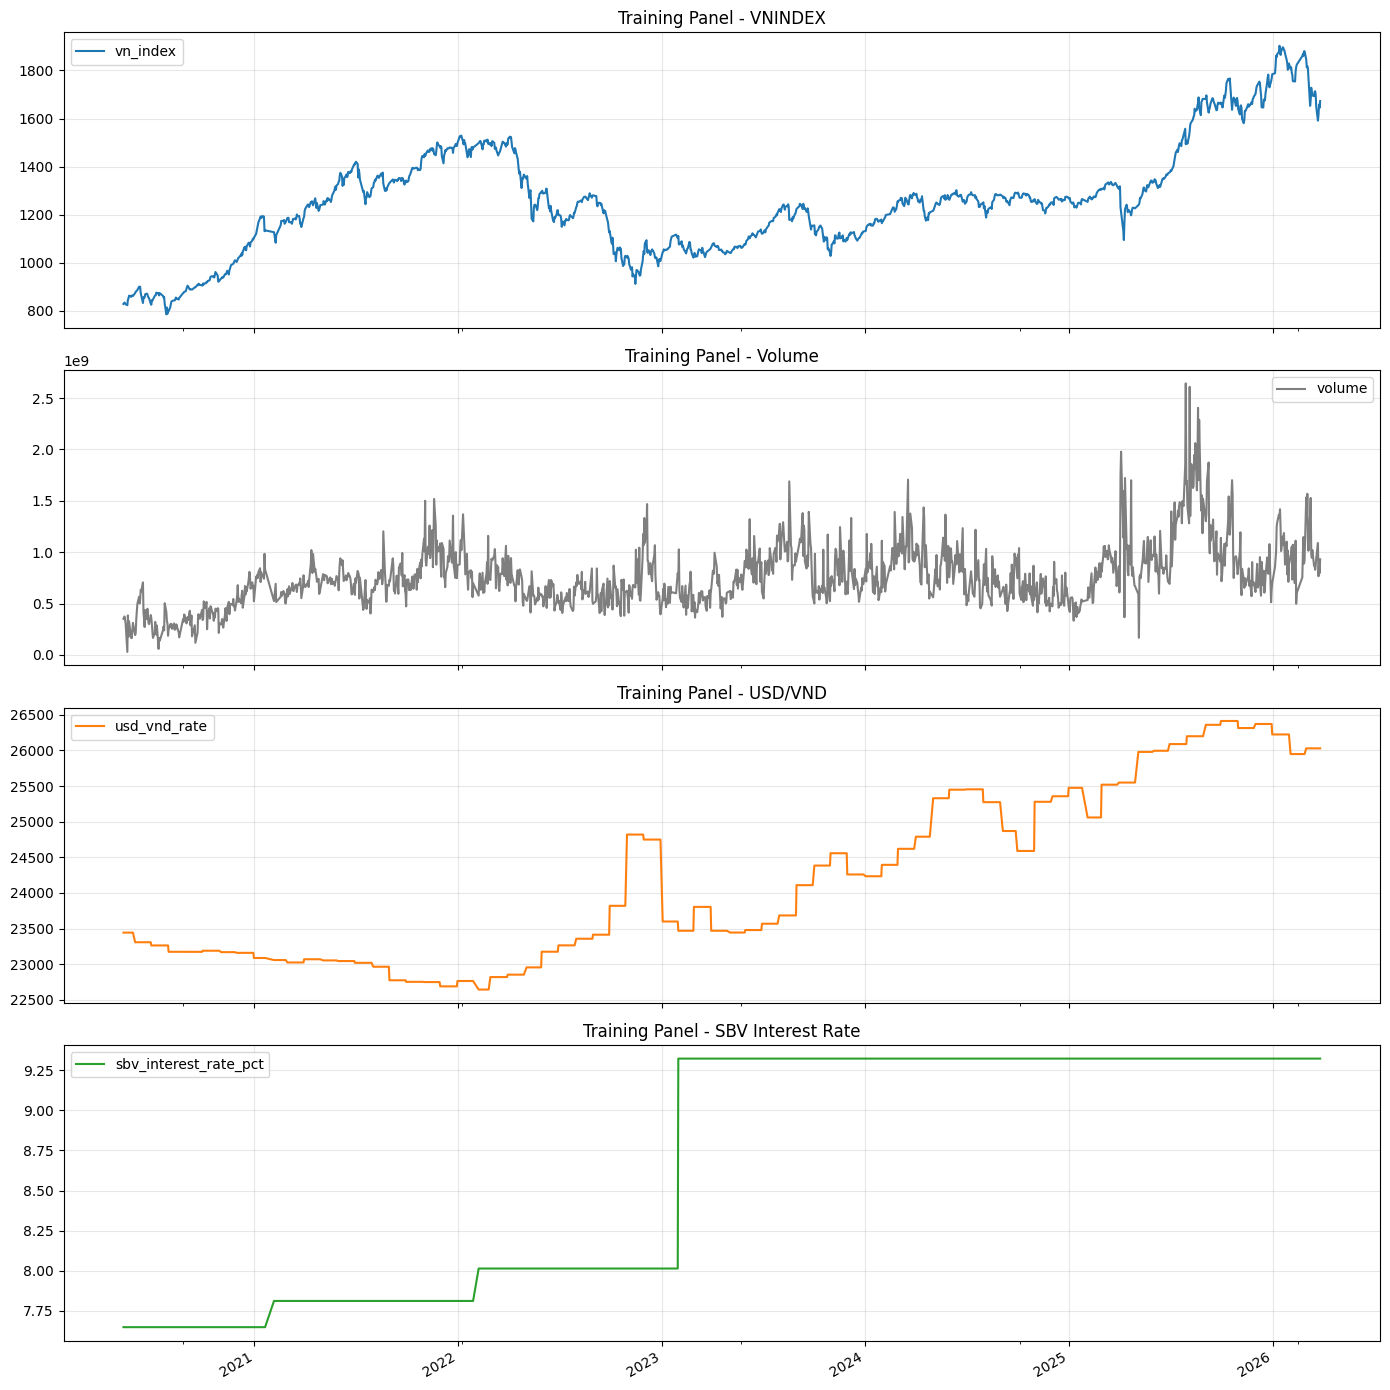

In [5]:
display(Markdown('## Training Panel Overview'))
display(pd.DataFrame({
    'metric': ['panel_rows', 'panel_start', 'panel_end', 'panel_columns'],
    'value': [len(panel_df), panel_df['date'].min(), panel_df['date'].max(), ', '.join(panel_df.columns)],
}))
display(panel_df.head())

fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
panel_df.plot(x='date', y='vn_index', ax=axes[0], color='tab:blue', title='Training Panel - VNINDEX')
panel_df.plot(x='date', y='volume', ax=axes[1], color='tab:gray', title='Training Panel - Volume')
panel_df.plot(x='date', y='usd_vnd_rate', ax=axes[2], color='tab:orange', title='Training Panel - USD/VND')
panel_df.plot(x='date', y='sbv_interest_rate_pct', ax=axes[3], color='tab:green', title='Training Panel - SBV Interest Rate')
for ax in axes:
    ax.grid(alpha=0.3)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

## Processing cụ thể: raw -> panel -> features

Luồng dữ liệu hiện tại trong project:
1. `VN30 raw parquet`: bảng long format, mỗi dòng là `1 ngày x 1 mã`
2. `VNINDEX raw parquet`: chuỗi chỉ số market-level để dùng cho training panel hiện tại
3. `training panel parquet`: `VNINDEX` đã được ghép với macro (`USD/VND`, `CPI`, `SBV rate`, `FDI proxy`) và thêm `volume_1w_trend_pct`
4. `prepare_features(...)`: sinh thêm rolling return, volatility, drawdown, MA gaps, slope, và nhãn `label_decline_1w/2w/1m`

Phần dưới sẽ show rõ số lượng cột, số lượng missing và số dòng usable sau mỗi bước.

In [6]:
raw_step = pd.DataFrame(
    {
        'step': ['VNINDEX raw', 'Training panel', 'Feature frame'],
        'rows': [len(vnindex_df), len(panel_df), len(panel_features_df)],
        'columns': [len(vnindex_df.columns), len(panel_df.columns), len(panel_features_df.columns)],
    }
)

display(raw_step)

feature_availability = []
for col in FEATURE_COLS:
    feature_availability.append({
        'feature': col,
        'non_null_rows': int(panel_features_df[col].notna().sum()),
        'null_rows': int(panel_features_df[col].isna().sum()),
        'pct_non_null': float(panel_features_df[col].notna().mean()),
    })
feature_availability_df = pd.DataFrame(feature_availability).sort_values('pct_non_null', ascending=False)
display(feature_availability_df)

label_availability = []
for horizon, spec in HORIZON_SPECS.items():
    usable_mask = panel_features_df[FEATURE_COLS].notna().all(axis=1) & panel_features_df[spec.label_col].notna()
    label_availability.append({
        'horizon': horizon,
        'label_column': spec.label_col,
        'label_available_rows': int(panel_features_df[spec.label_col].notna().sum()),
        'usable_rows_after_features': int(usable_mask.sum()),
        'positive_rate': float(panel_features_df.loc[usable_mask, spec.label_col].mean()) if usable_mask.any() else None,
    })
label_availability_df = pd.DataFrame(label_availability)
display(label_availability_df)

,step,rows,columns
0,VNINDEX raw,1437,7
1,Training panel,1437,9
2,Feature frame,1437,25


,feature,non_null_rows,null_rows,pct_non_null
0,usd_vnd_rate,1437,0,1.000000
1,usd_vnd_1m_change_pct,1437,0,1.000000
2,sbv_interest_rate_pct,1437,0,1.000000
3,cpi_yoy_pct,1437,0,1.000000
4,ret_5d,1432,5,0.996521
5,ret_10d,1427,10,0.993041
7,realized_vol_10d,1427,10,0.993041
9,drawdown_20d,1418,19,0.986778
10,vol_z,1418,19,0.986778
11,ma_gap_20,1418,19,0.986778


,horizon,label_column,label_available_rows,usable_rows_after_features,positive_rate
0,1w,label_decline_1w,1432,1383,0.256688
1,2w,label_decline_2w,1427,1378,0.258345
2,1m,label_decline_1m,1416,1367,0.199707


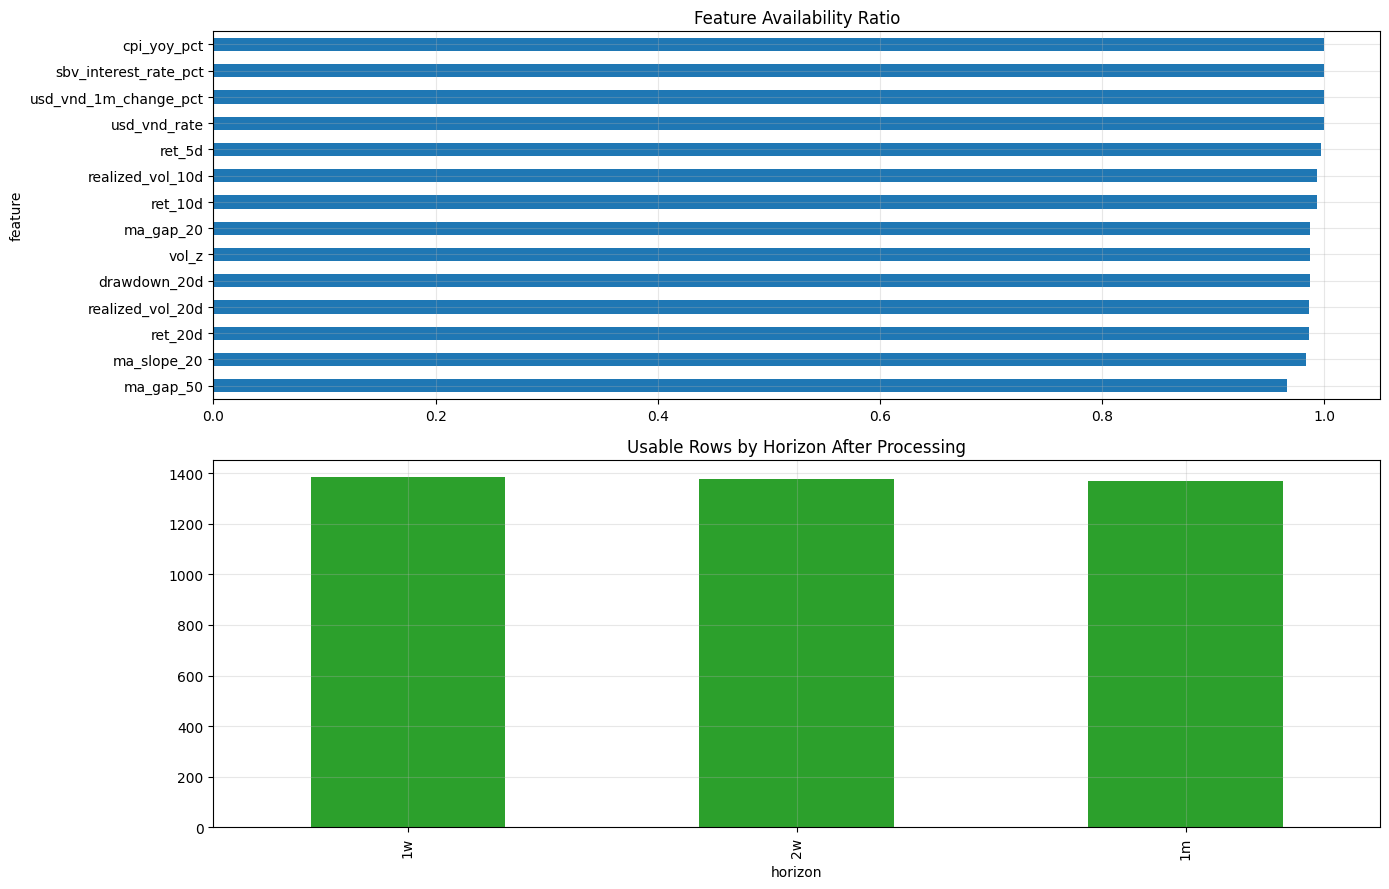

,date,vn_index,usd_vnd_rate,ret_5d,ret_10d,ret_20d,realized_vol_20d,drawdown_20d,ma_gap_50,label_decline_1w,label_decline_2w,label_decline_1m
1422,2026-03-09,1652.79,26030.0,-0.104713,-0.111470,-0.085087,0.084110,-0.121011,-0.090840,0.0,1.0,NaN
1423,2026-03-10,1676.73,26030.0,-0.075234,-0.102210,-0.075367,0.085847,-0.108279,-0.077391,0.0,1.0,NaN
1424,2026-03-11,1728.34,26030.0,-0.049459,-0.071239,-0.035218,0.091938,-0.080832,-0.048756,0.0,1.0,NaN
1425,2026-03-12,1709.61,26030.0,-0.054686,-0.090459,-0.040924,0.092352,-0.090793,-0.058416,0.0,1.0,NaN
1426,2026-03-13,1696.24,26030.0,-0.040501,-0.097903,-0.033751,0.091525,-0.097903,-0.064888,1.0,0.0,NaN
1427,2026-03-16,1693.21,26030.0,0.024456,-0.082818,-0.035109,0.091517,-0.099514,-0.066047,1.0,NaN,NaN
1428,2026-03-17,1710.29,26030.0,0.020015,-0.056725,-0.024937,0.092258,-0.090431,-0.056423,1.0,NaN,NaN
1429,2026-03-18,1713.83,26030.0,-0.008395,-0.057439,-0.046203,0.088390,-0.088548,-0.054042,1.0,NaN,NaN
1430,2026-03-19,1699.13,26030.0,-0.006130,-0.060481,-0.063371,0.087709,-0.096366,-0.061454,1.0,NaN,NaN
1431,2026-03-20,1647.81,26030.0,-0.028551,-0.067896,-0.096640,0.091227,-0.123659,-0.088425,0.0,NaN,NaN


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)
feature_availability_df.sort_values('pct_non_null').plot.barh(x='feature', y='pct_non_null', ax=axes[0], color='tab:blue', legend=False, title='Feature Availability Ratio')
label_availability_df.plot.bar(x='horizon', y='usable_rows_after_features', ax=axes[1], color='tab:green', legend=False, title='Usable Rows by Horizon After Processing')
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

process_preview_cols = [
    'date', 'vn_index', 'usd_vnd_rate', 'ret_5d', 'ret_10d', 'ret_20d',
    'realized_vol_20d', 'drawdown_20d', 'ma_gap_50', 'label_decline_1w', 'label_decline_2w', 'label_decline_1m'
]
display(panel_features_df[process_preview_cols].tail(15))

In [8]:
display(Markdown('## Key Takeaways'))

coverage_notes = pd.DataFrame(
    {
        'topic': [
            'VN30 universe',
            'VNINDEX training base',
            'Current model input',
            'Why some features/labels have NaN',
        ],
        'detail': [
            f"{vn30_df['ticker'].nunique()} tickers, {len(vn30_df):,} raw daily rows",
            f"{len(vnindex_df):,} VNINDEX rows from {vnindex_df['time'].min().date()} to {vnindex_df['time'].max().date()}",
            f"Training panel has {len(panel_df):,} rows and {len(panel_df.columns)} columns before feature engineering",
            'Rolling features need lookback window; labels need future horizon, so head/tail rows naturally become unavailable for some steps',
        ],
    }
)
display(coverage_notes)

## Key Takeaways

,topic,detail
0,VN30 universe,"30 tickers, 73,410 raw daily rows"
1,VNINDEX training base,"1,437 VNINDEX rows from 2020-05-11 to 2026-03-27"
2,Current model input,"Training panel has 1,437 rows and 9 columns be..."
3,Why some features/labels have NaN,Rolling features need lookback window; labels ...
